# 04 — Modèle de référence : régression logistique

Je commence par un modèle simple et lisible. Il fixe le niveau à battre et, surtout, ses
coefficients se lisent directement.

Rappel du cadre : on prédit le syndrome métabolique **sans** les mesures qui le
définissent (tour de taille, IMC, tension, bilan lipidique, glycémie) et sans les
traitements associés. Uniquement démographie + alimentation + mode de vie. `src/features.py`
fait la sélection et vérifie qu'aucune variable de définition ne se glisse en entrée.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 60)
from sklearn.model_selection import train_test_split
from src import features, modeling, plotting
df = pd.read_parquet(ROOT / "data" / "processed" / "analytique.parquet")
X, y = features.matrice_X_y(df)
print("X :", X.shape, " | prévalence :", round(y.mean(), 3))
X.dtypes.value_counts()

X : (5405, 32)  | prévalence : 0.325


float64    26
object      6
Name: count, dtype: int64

In [2]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print(f"train {len(X_tr)}  |  test {len(X_te)}  (mis de côté jusqu'au notebook 05)")

train 4053  |  test 1352  (mis de côté jusqu'au notebook 05)


Le pipeline fait tout le pré-traitement à l'intérieur de la validation croisée :
imputation médiane (+ indicateur de valeur manquante), standardisation, one-hot pour les
catégorielles. Rien n'est ajusté sur le test.

Métrique de suivi : **average precision** (aire sous la courbe précision-rappel). Avec
~1 sur 3 de positifs, l'accuracy ne veut rien dire et l'AP est plus parlante que l'AUC ROC
pour un usage de ciblage.

In [3]:
logit = modeling.modeles()["Régression logistique"]
res = modeling.comparer({"Régression logistique": logit}, X_tr, y_tr)
res

,AP (PR-AUC),AP ± σ,ROC AUC,Brier
modèle,,,,
Régression logistique,0.4712,0.0191,0.677,0.227


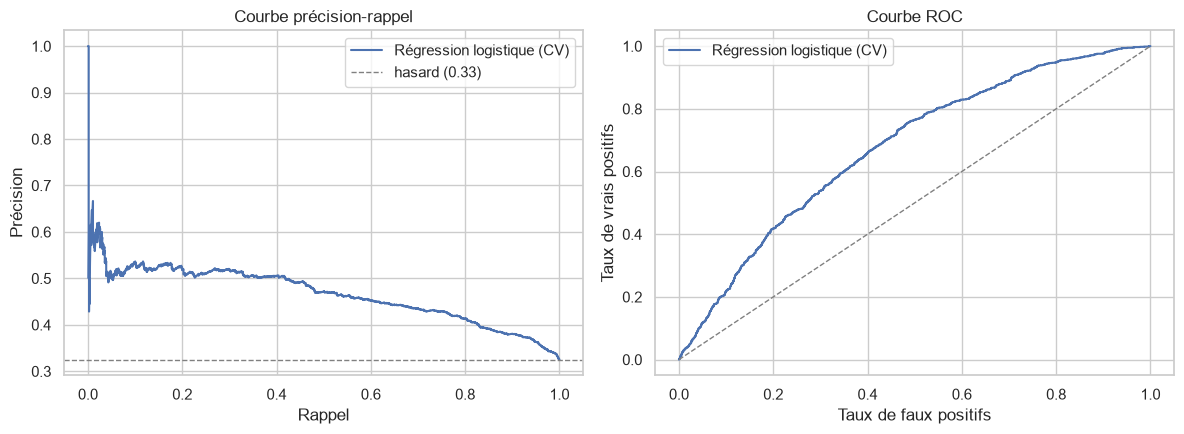

In [4]:
from sklearn.model_selection import cross_val_predict
scores_cv = cross_val_predict(logit, X_tr, y_tr, cv=modeling.CV, method="predict_proba")[:, 1]
fig = plotting.courbes_pr_roc({"Régression logistique (CV)": (y_tr.values, scores_cv)})
plotting.save(fig, "04_pr_roc_baseline")
plt.show()

AUC ROC autour de **0,68**, AP autour de **0,47** pour une prévalence de 0,33. Traduction :
le modèle classe correctement deux personnes tirées au hasard (une avec, une sans
syndrome) environ 68 fois sur 100. C'est mieux que le hasard, nettement en dessous d'un
modèle cliniquement utilisable. Pour une prédiction basée uniquement sur des déclarations
de mode de vie, c'est à peu près ce qu'on pouvait espérer.

In [5]:
# Lecture des coefficients (odds ratios) du modèle entraîné sur tout le train.
logit.fit(X_tr, y_tr)
prep = logit.named_steps["prep"]
noms = prep.get_feature_names_out()
coefs = pd.Series(logit.named_steps["clf"].coef_[0], index=noms)
coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15)
tab = pd.DataFrame({"coef": coefs, "odds ratio": np.exp(coefs)}).round(3)
tab

,coef,odds ratio
num__lipides_g,0.877,2.404
num__age,0.598,1.819
num__ags_g,-0.465,0.628
cat__origine_Asiatique non hispanique,-0.360,0.698
num__agpi_g,-0.358,0.699
cat__origine_Noir non hispanique,-0.325,0.723
cat__origine_Hispanique (Mexique),0.311,1.365
num__potassium_mg,-0.235,0.790
num__energie_kcal,-0.231,0.794
num__activite_met_min_sem,-0.206,0.814


Sans surprise, l'âge domine. Viennent ensuite le sexe et l'origine, puis — plus
intéressant pour le propos — quelques variables de mode de vie : la sédentarité pousse le
risque vers le haut, l'activité physique et une alimentation plus riche en fibres le
tirent légèrement vers le bas. Les effets alimentaires sont réels dans le signe mais
petits en amplitude.

On garde ce modèle comme référence. Le notebook 05 teste si des modèles non linéaires font
mieux, et surtout **quantifie l'apport de chaque bloc de variables**.

In [6]:
import joblib
joblib.dump({"pipeline": logit, "X_te": X_te, "y_te": y_te, "X_tr": X_tr, "y_tr": y_tr},
            ROOT / "models" / "baseline_logit.joblib")
print("modèle de référence + split sauvegardés")

modèle de référence + split sauvegardés
